IMPORT LIBRARIES

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import string
import nltk

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
from nltk.tokenize import word_tokenize

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve
)

# Tensor flow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    GlobalAveragePooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Transformers

import transformers
import datasets
import pyarrow

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
project_path = '/content/drive/MyDrive/Fake News Project'
os.makedirs(project_path, exist_ok=True)

LOAD DATASET

In [4]:

# Load datasets
train_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fake News Project/data/training_data.csv", delimiter = "\t", header = None)
test_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Fake News Project/data/testing_data.csv" , delimiter = "\t", header = None)


In [5]:
# DISPLAY BASIC INFORMATION

print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)


# Display first 5 rows
train_df.head()

Training Dataset Shape: (34152, 2)
Testing Dataset Shape: (9984, 2)


,0,1
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...


In [6]:
# Renamed the columns as label and text
train_df.columns = ['label', 'text']
test_df.columns = ['label', 'text']
train_df
test_df

,label,text
0,2,copycat muslim terrorist arrested with assault...
1,2,wow! chicago protester caught on camera admits...
2,2,germany's fdp look to fill schaeuble's big shoes
3,2,mi school sends welcome back packet warning ki...
4,2,u.n. seeks 'massive' aid boost amid rohingya '...
...,...,...
9979,2,boom! fox news leftist chris wallace attempts ...
9980,2,here it is: list of democrat hypocrites who vo...
9981,2,new fires ravage rohingya villages in northwes...
9982,2,meals on wheels shuts the lyin‚ lefties up wit...


EXPLORATORY DATA ANALYSIS (EDA)

In [7]:
# CHECK DATASET INFO


print("\nTraining Dataset Info:\n")
train_df.info()


Training Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34152 entries, 0 to 34151
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   34152 non-null  int64 
 1   text    34152 non-null  object
dtypes: int64(1), object(1)
memory usage: 533.8+ KB


VISUAL OF TEXT LENGTH DISTRIBUTION

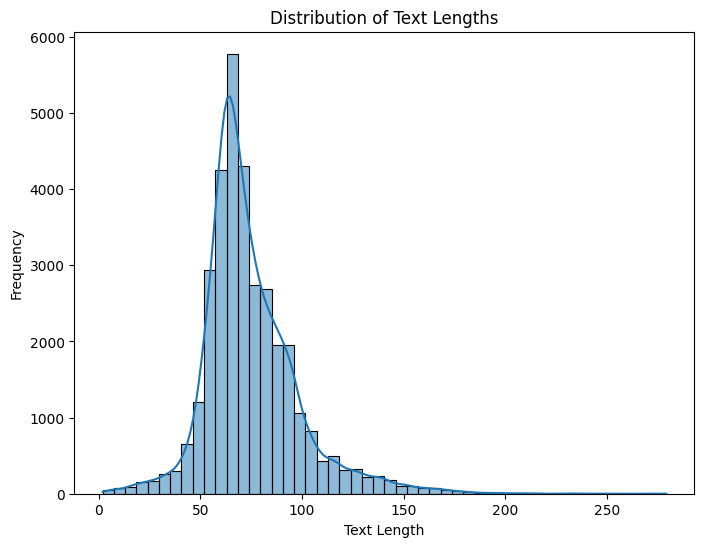

In [8]:
train_df['text_length'] = train_df['text'].apply(len)

plt.figure(figsize=(8,6))

sns.histplot(
    train_df['text_length'],
    bins=50,
    kde=True
)

plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')

plt.show()

TEXT LENGTH BY CLASS KDE PLOT

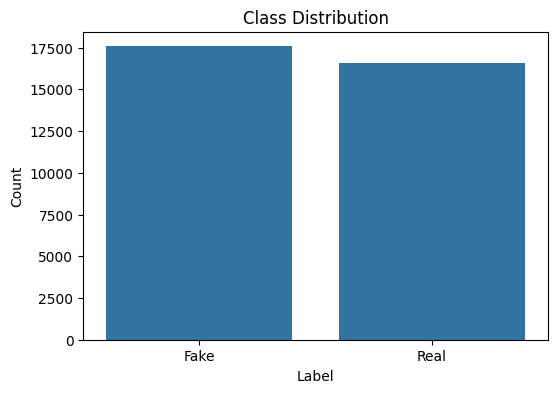

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='label',
    data=train_df
)

plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')

plt.xticks([0,1], ['Fake', 'Real'])

plt.show()

FAKE VS REAL TEXT LENGTH

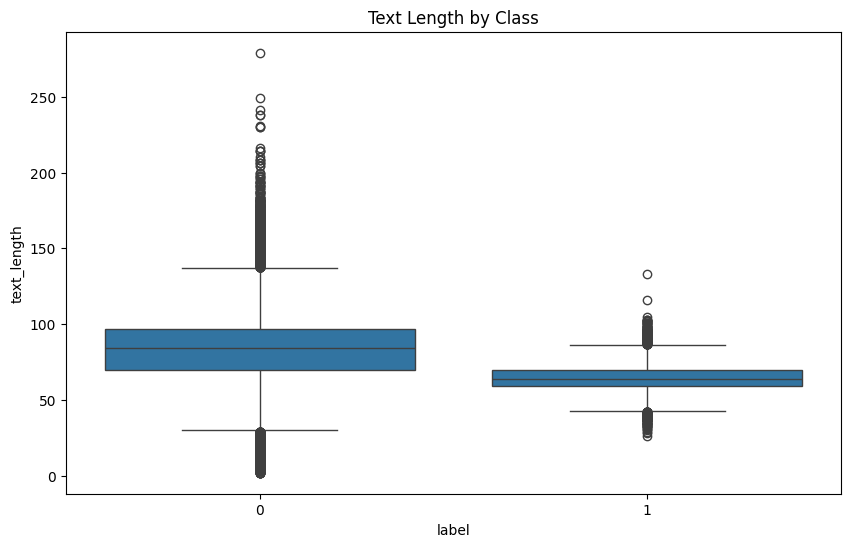

In [10]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='label',
    y='text_length',
    data=train_df
)

plt.title('Text Length by Class')

plt.show()

In [11]:
# CHECK MISSING VALUES


print("\nMissing Values in Training Dataset:\n")
print(train_df.isnull().sum())


print("\nMissing Values in Testing Dataset:\n")
print(test_df.isnull().sum())


Missing Values in Training Dataset:

label          0
text           0
text_length    0
dtype: int64

Missing Values in Testing Dataset:

label    0
text     0
dtype: int64


In [12]:
# CHECK DUPLICATES


print("\nDuplicate Rows in Training Dataset:", train_df.duplicated().sum())
print("Duplicate Rows in Testing Dataset:", test_df.duplicated().sum())


Duplicate Rows in Training Dataset: 1946
Duplicate Rows in Testing Dataset: 775


In [13]:
train_df['text'].duplicated().sum()


np.int64(1946)

In [14]:
test_df['text'].duplicated().sum()

np.int64(776)

In [15]:
train_df[train_df['text'].duplicated()]

,label,text,text_length
1534,0,mcconnell says he‚ll obstruct any effort to hi...,79
3054,0,no,2
4047,0,trump freaks out,16
4963,0,as trump collapses,18
5141,0,no,2
...,...,...,...
34047,1,u.s. has lost trust in south sudan\ttrump envo...,62
34049,1,u.s. house passes sanctions on iran-backed hez...,52
34054,1,trump declines to say if he will visit korean ...,62
34126,1,thailand kicks off sumptuous funeral of king b...,63


In [16]:
train_df[train_df['text'].duplicated(keep = False)]

,label,text,text_length
678,0,thanks to trump,15
986,0,no,2
1487,0,mcconnell says he‚ll obstruct any effort to hi...,79
1534,0,mcconnell says he‚ll obstruct any effort to hi...,79
1619,0,trump freaks out,16
...,...,...,...
34049,1,u.s. house passes sanctions on iran-backed hez...,52
34053,1,thailand kicks off sumptuous funeral of king b...,63
34054,1,trump declines to say if he will visit korean ...,62
34126,1,thailand kicks off sumptuous funeral of king b...,63


In [17]:
# REMOVE DUPLICATES


train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

print("\nShape After Removing Duplicates:")
print("Training:", train_df.shape)
print("Testing:", test_df.shape)



Shape After Removing Duplicates:
Training: (32206, 3)
Testing: (9209, 2)


DATA CLEANING

In [18]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [19]:
def clean_text(text):

    # lowercase
    text = text.lower()

    # remove punctuation
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    # tokenize
    words = text.split()

    # remove stopwords + lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

PREPROCESSING

In [20]:
train_df['clean_text'] = train_df['text'].apply(clean_text)

test_df['clean_text'] = test_df['text'].apply(clean_text)

In [21]:
train_df.head()


,label,text,text_length,clean_text
0,0,donald trump sends out embarrassing new year‚s...,78,donald trump sends embarrassing new year‚s eve...
1,0,drunk bragging trump staffer started russian c...,68,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...,89,sheriff david clarke becomes internet joke thr...
3,0,trump is so obsessed he even has obama‚s name ...,77,trump obsessed even obama‚s name coded website...
4,0,pope francis just called out donald trump duri...,69,pope francis called donald trump christmas speech


In [22]:
test_df.head()

,label,text,clean_text
0,2,copycat muslim terrorist arrested with assault...,copycat muslim terrorist arrested assault weapon
1,2,wow! chicago protester caught on camera admits...,wow chicago protester caught camera admits vio...
2,2,germany's fdp look to fill schaeuble's big shoes,germany fdp look fill schaeuble big shoe
3,2,mi school sends welcome back packet warning ki...,mi school sends welcome back packet warning ki...
4,2,u.n. seeks 'massive' aid boost amid rohingya '...,u n seek massive aid boost amid rohingya emerg...


MOST COMMON WORDS

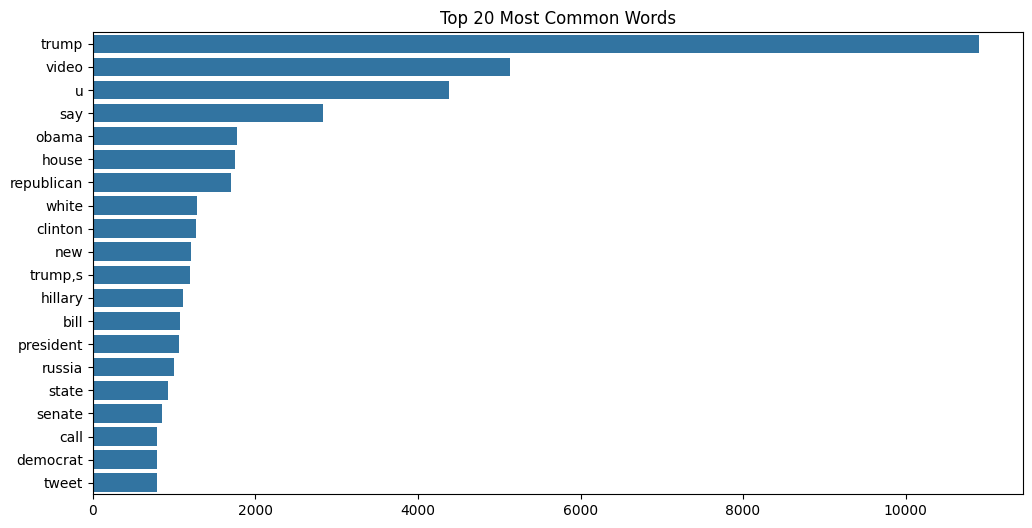

In [23]:
from collections import Counter

all_words = " ".join(train_df['clean_text']).split()

common_words = Counter(all_words).most_common(20)

words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]

plt.figure(figsize=(12,6))

sns.barplot(
    x=counts,
    y=words
)

plt.title('Top 20 Most Common Words')

plt.show()

WORD CLOUD

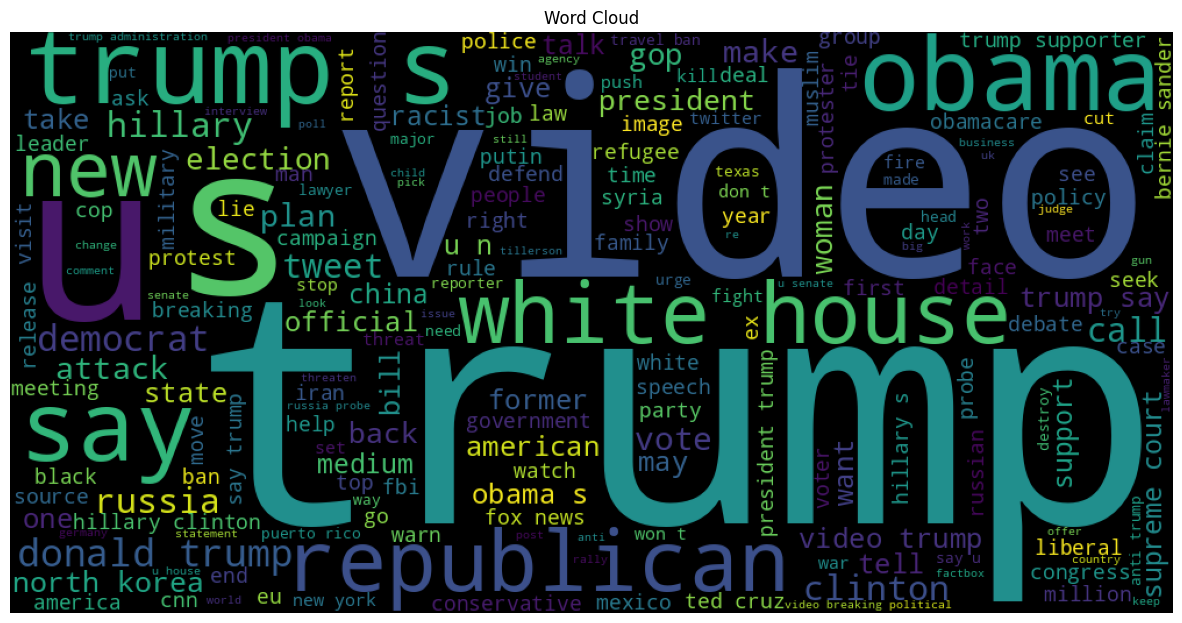

In [24]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='black'
).generate(" ".join(train_df['clean_text']))

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('Word Cloud')

plt.show()

WORD COUNT DISTRIBUTION

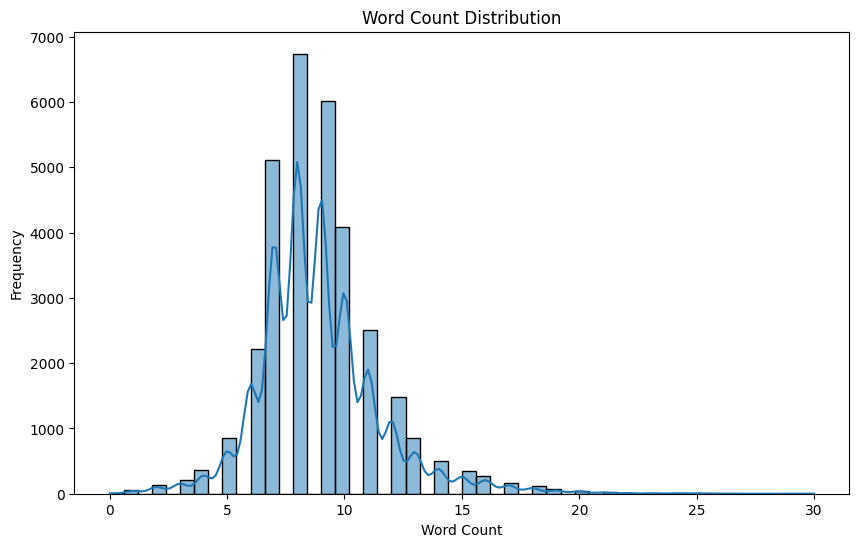

In [25]:
train_df['word_count'] = train_df['clean_text'].apply(
    lambda x: len(x.split())
)

plt.figure(figsize=(10,6))

sns.histplot(
    train_df['word_count'],
    bins=50,
    kde=True
)

plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.show()

TOP WORDS FOR FAKE NEWS

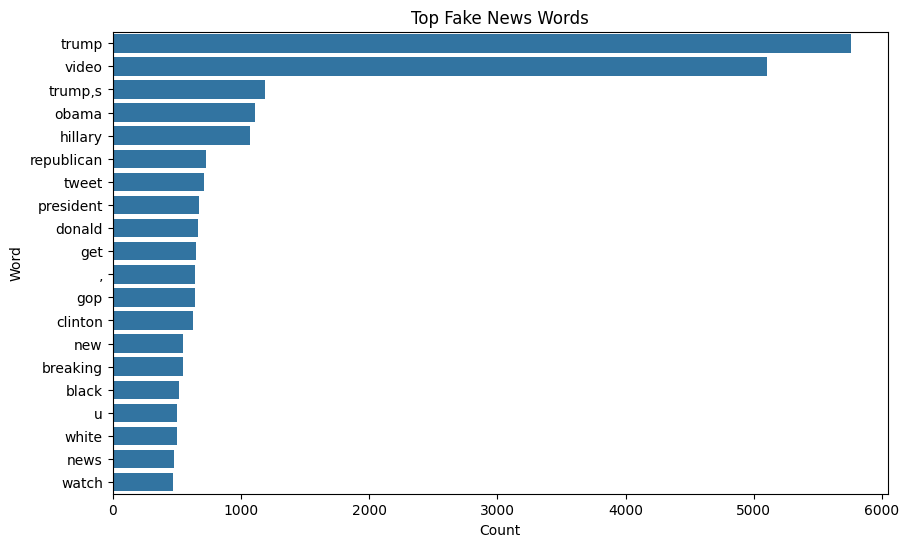

In [26]:
fake_words = ' '.join(
    train_df[
        train_df['label'] == 0
    ]['clean_text']
).split()

fake_common = Counter(fake_words).most_common(20)

fake_df = pd.DataFrame(
    fake_common,
    columns=['Word', 'Count']
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Count',
    y='Word',
    data=fake_df
)

plt.title('Top Fake News Words')

plt.show()

TOP WORDS FOR REAL NEWS

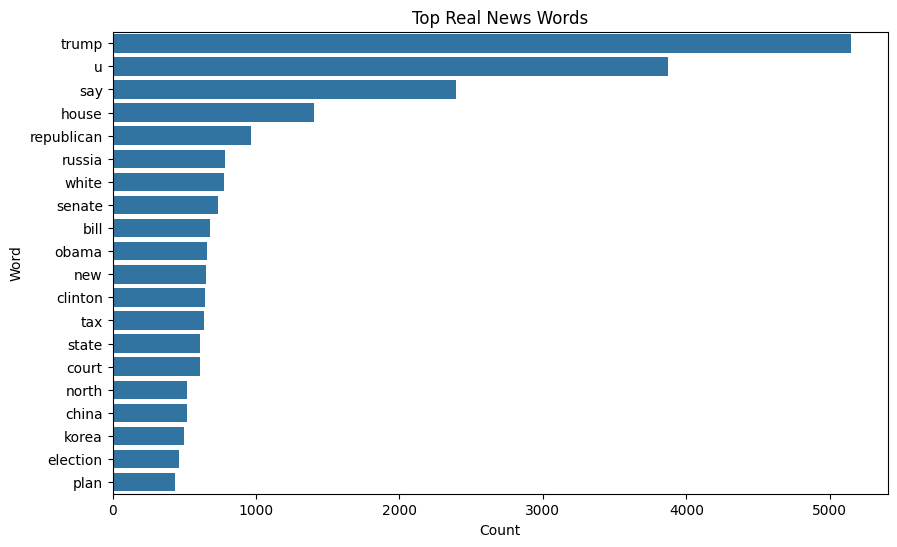

In [27]:
real_words = ' '.join(
    train_df[
        train_df['label'] == 1
    ]['clean_text']
).split()

real_common = Counter(real_words).most_common(20)

real_df = pd.DataFrame(
    real_common,
    columns=['Word', 'Count']
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Count',
    y='Word',
    data=real_df
)

plt.title('Top Real News Words')

plt.show()

In [ ]:
# NOTE:
# Text preprocessing is intentionally performed BEFORE train-test split.
# This preprocessing only includes:
# - lowercasing
# - punctuation removal
# - stopword removal
# - lemmatization
#
# No vocabulary learning occurs before splitting.
# Vectorizers and tokenizers are fit ONLY on training data,
# preventing data leakage.

TRAIN-TEST SPLIT

In [28]:
X = train_df['clean_text']
y = train_df['label']

In [29]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

FEATURE ENGINEERING USING BAG OF WORDS

In [30]:


bow_vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_valid_bow = bow_vectorizer.transform(X_valid)

# Print shape of vectorized dataset
print(X_train_bow.shape)
print(X_valid_bow.shape)

### then we continue on our classifier of choice

(25764, 5000)
(6442, 5000)



LOGISTIC REGRESSION USING BAG OF WORDS

In [31]:
from sklearn.linear_model import LogisticRegression

INITIALIZE MODEL

In [32]:

lr_bow = LogisticRegression(max_iter=1000)

TRAIN MODEL

In [33]:

lr_bow.fit(X_train_bow, y_train)

LogisticRegression(max_iter=1000)

PREDICTIONS

In [34]:

y_pred_bow = lr_bow.predict(X_valid_bow)

EVALUATE MODEL

In [35]:
# Accuracy
accuracy_bow = accuracy_score(y_valid, y_pred_bow)
print("BoW Logistic Regression Accuracy:", accuracy_bow)

# F1 score
f1_bow = f1_score(y_valid, y_pred_bow, average='weighted')
print("BoW Logistic Regression F1 Score:", f1_bow)


BoW Logistic Regression Accuracy: 0.9279726792921453
BoW Logistic Regression F1 Score: 0.9279400517295461


CLASSIFICATION REPORT

In [36]:

print(classification_report(y_valid, y_pred_bow))

              precision    recall  f1-score   support

           0       0.94      0.91      0.93      3205
           1       0.91      0.95      0.93      3237

    accuracy                           0.93      6442
   macro avg       0.93      0.93      0.93      6442
weighted avg       0.93      0.93      0.93      6442



CONFUSION MATRIX

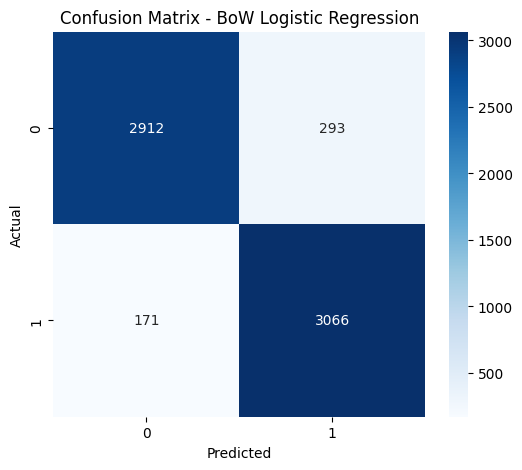

In [37]:

cm = confusion_matrix(y_valid, y_pred_bow)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - BoW Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

FEATURE ENGINEERING USING TF-IDF

In [38]:
# Vectorize all dataset
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

# Fit & Transform
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_valid_tfidf = tfidf_vectorizer.transform(X_valid)

# Print shape of vectorized dataset
print(X_train_tfidf.shape)
print(X_valid_tfidf.shape)


(25764, 5000)
(6442, 5000)


LOGISTIC REGRESSION USING TF-IDF

INITIALIZE MODEL

In [39]:

lr_tfidf = LogisticRegression(max_iter=1000)

TRAIN MODEL

In [40]:

lr_tfidf.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

PREDICTIONS

In [41]:

y_pred_tfidf = lr_tfidf.predict(X_valid_tfidf)

EVALUATE TF - IDF MODEL

In [42]:
# Accuracy
accuracy_tfidf = accuracy_score(y_valid, y_pred_tfidf)
print("TF-IDF Logistic Regression Accuracy:", accuracy_tfidf)

# F1 score
f1_tfidf = f1_score(y_valid, y_pred_tfidf, average='weighted')
print("TF-IDF Logistic Regression F1 Score:", f1_tfidf)

TF-IDF Logistic Regression Accuracy: 0.9257994411673394
TF-IDF Logistic Regression F1 Score: 0.9257749923048966


CLASSIFICATION REPORT

In [43]:

print(classification_report(y_valid, y_pred_tfidf))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92      3205
           1       0.91      0.94      0.93      3237

    accuracy                           0.93      6442
   macro avg       0.93      0.93      0.93      6442
weighted avg       0.93      0.93      0.93      6442



CONFUSION MATRIX

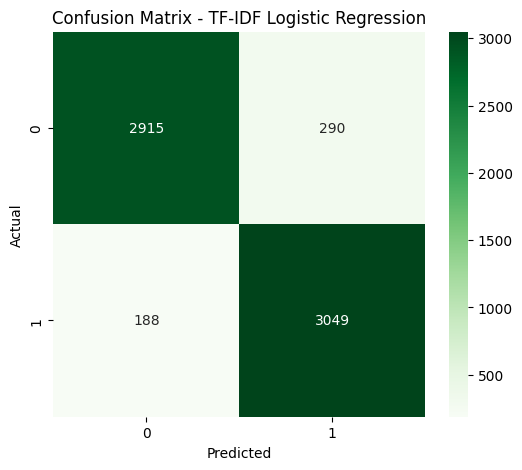

In [44]:

cm = confusion_matrix(y_valid, y_pred_tfidf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - TF-IDF Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

COMPARE BOTH METHODS

In [45]:
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression + BoW',
        'Logistic Regression + TF-IDF'
    ],
    'Accuracy': [
        accuracy_bow,
        accuracy_tfidf
    ],
    'F1 Score': [
        f1_bow,
        f1_tfidf
    ]
})

comparison_df

,Model,Accuracy,F1 Score
0,Logistic Regression + BoW,0.927973,0.927940
1,Logistic Regression + TF-IDF,0.925799,0.925775


HEATMAP OF MATRICS

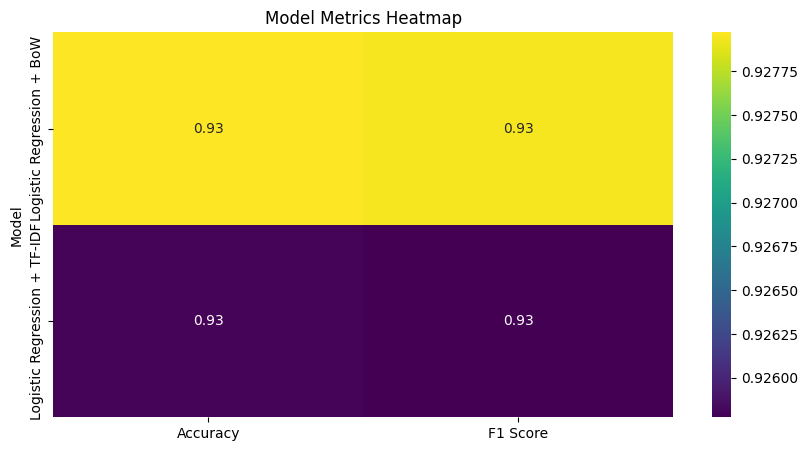

In [46]:
metrics_df = comparison_df.set_index('Model')

plt.figure(figsize=(10,5))

sns.heatmap(
    metrics_df,
    annot=True,
    cmap='viridis'
)

plt.title('Model Metrics Heatmap')

plt.show()

SELECT BEST MODEL

In [47]:
if accuracy_tfidf > accuracy_bow:
    best_model = lr_tfidf
    best_vectorizer = tfidf_vectorizer
    print("TF-IDF Logistic Regression Selected")
else:
    best_model = lr_bow
    best_vectorizer = bow_vectorizer
    print("BoW Logistic Regression Selected")

BoW Logistic Regression Selected


BASELINE RANDOM FOREST MODEL USING BAG OF WORDS

CREATE RANDOMFOREST MODEL

In [48]:

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

TRAIN MODEL

In [49]:

rf_model.fit(X_train_bow, y_train)


RandomForestClassifier(max_depth=20, n_estimators=200, n_jobs=-1,
                       random_state=42)

PREDICTIONS

In [50]:

y_pred_rf = rf_model.predict(X_valid_bow)


EVALUATION METRICS

In [51]:

# Accuracy
rf_accuracy = accuracy_score(y_valid, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)
# F1 score
rf_f1 = f1_score(y_valid, y_pred_rf, average='weighted')
print("Random Forest F1 Score:", rf_f1)


Random Forest Accuracy: 0.8511331884507917
Random Forest F1 Score: 0.8495782350375083


CLASSIFICATION REPORT

In [52]:

print(classification_report(y_valid, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.75      0.83      3205
           1       0.79      0.95      0.87      3237

    accuracy                           0.85      6442
   macro avg       0.87      0.85      0.85      6442
weighted avg       0.87      0.85      0.85      6442



CONFUSION MATRIX

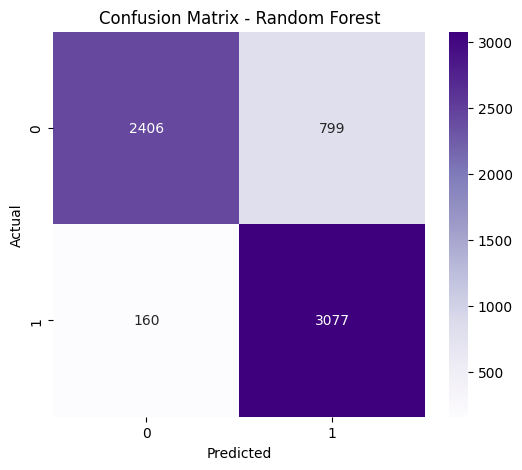

In [53]:

cm_rf = confusion_matrix(y_valid, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
plt.show()

HYPERPARAMETER TUNING FOR RANDOMFOREST USING GRIDSEARCHCV

In [54]:
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


INITIALIZE BASE RANDOMFOREST

In [55]:
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

GRID SEARCH

In [56]:
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

TRAIN GRIDSEARCH

In [57]:

grid_search_rf.fit(X_train_bow, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=2)

BEST PARAMETERS

In [58]:
print("Best Parameters:")
print(grid_search_rf.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


BEST SCORE

In [59]:
print("Best Cross Validation Score:", grid_search_rf.best_score_)

Best Cross Validation Score: 0.8998990839931688


TRAIN TUNED RANDOMFOREST MODEL

In [60]:
best_rf_model = grid_search_rf.best_estimator_

PREDICTION ON VALIDATION SET

In [61]:
y_pred_best_rf = best_rf_model.predict(X_valid_bow)

EVALUATE

In [62]:
# Accuracy
best_rf_accuracy = accuracy_score(y_valid, y_pred_best_rf)
print("Tuned Random Forest Accuracy:", best_rf_accuracy)

# F1 score
best_rf_f1 = f1_score(y_valid, y_pred_best_rf, average='weighted')
print("Tuned Random Forest F1 Score:", best_rf_f1)

Tuned Random Forest Accuracy: 0.9071716858118597
Tuned Random Forest F1 Score: 0.9071702451998379


CLASSIFICATION REPORT

In [63]:

print(classification_report(y_valid, y_pred_best_rf))

              precision    recall  f1-score   support

           0       0.91      0.90      0.91      3205
           1       0.91      0.91      0.91      3237

    accuracy                           0.91      6442
   macro avg       0.91      0.91      0.91      6442
weighted avg       0.91      0.91      0.91      6442



CONFUSION MATRIX

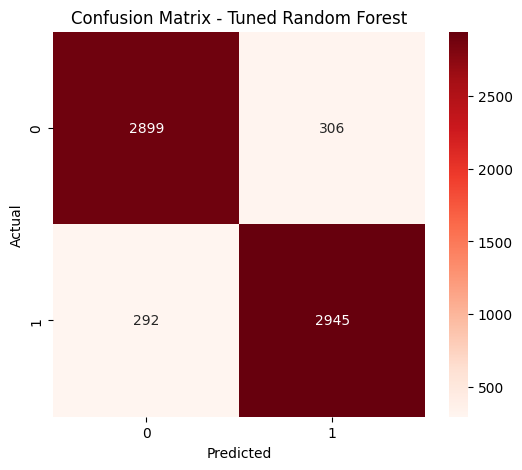

In [64]:

cm_best_rf = confusion_matrix(y_valid, y_pred_best_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_best_rf,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title('Confusion Matrix - Tuned Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

HYPERPARAMETER TUNING FOR RANDOMFOREST USING RANDOMSEARCHCV

Define Advanced Parameter Distribution

We will search across:

More tree counts
Different depths
Split criteria
Bootstrap options
Leaf sizes

In [65]:
# Define parameter grid
random_param_grid = {

    'n_estimators': [100, 200, 300, 500],

    'max_depth': [10, 20, 30, 50, None],

    'min_samples_split': [2, 5, 10],

    'min_samples_leaf': [1, 2, 4],

    'max_features': ['sqrt', 'log2'],

    'bootstrap': [True, False]
}

INITIALIZE RANDOMFOREST

In [66]:

rf_random = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

INITIALIZE RANDOMISEDSEARCHCV

In [67]:

random_search_rf = RandomizedSearchCV(

    estimator=rf_random,

    param_distributions=random_param_grid,

    n_iter=20,

    scoring='f1_weighted',

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

TRAIN RANDOMIZEDSEARCHCV

In [68]:

random_search_rf.fit(X_train_bow, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 50, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='f1_weighted', verbose=2)

In [69]:
# Best parameters
print("Best Parameters:")
print(random_search_rf.best_params_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}


In [70]:
# Best cross validation score
print("Best Cross Validation F1 Score:")
print(random_search_rf.best_score_)

Best Cross Validation F1 Score:
0.9198045972388021


In [71]:
# Retrieve best RandomForest model
best_random_rf = random_search_rf.best_estimator_

PREDICTIONS

In [72]:

y_pred_random_rf = best_random_rf.predict(X_valid_bow)

EVALUATE ADVANCED TUNED RANDOMFOREST

In [73]:
# Accuracy
advanced_rf_accuracy = accuracy_score(
    y_valid,
    y_pred_random_rf
)

print("Advanced Tuned RF Accuracy:", advanced_rf_accuracy)

# F1 score
advanced_rf_f1 = f1_score(
    y_valid,
    y_pred_random_rf,
    average='weighted'
)

print("Advanced Tuned RF F1 Score:", advanced_rf_f1)

Advanced Tuned RF Accuracy: 0.9237814343371624
Advanced Tuned RF F1 Score: 0.9237763481183001


CLASSIFICATION REPORT

In [74]:

print(classification_report(
    y_valid,
    y_pred_random_rf
))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      3205
           1       0.92      0.93      0.92      3237

    accuracy                           0.92      6442
   macro avg       0.92      0.92      0.92      6442
weighted avg       0.92      0.92      0.92      6442



CONFUSION MATRIX

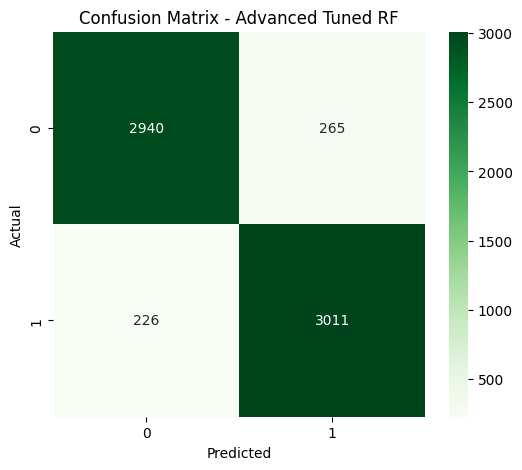

In [75]:

cm_advanced_rf = confusion_matrix(
    y_valid,
    y_pred_random_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_advanced_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Confusion Matrix - Advanced Tuned RF')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

BILSTM TRAINABLE EMBEDDING

TOKENIZATION

In [76]:
# Vocabulary size
vocab_size = 10000

# Maximum sequence length
max_length = 200

# Tokenizer
tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token='<OOV>'
)

# Fit tokenizer
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_valid_seq = tokenizer.texts_to_sequences(X_valid)

# Padding
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_valid_pad = pad_sequences(
    X_valid_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print(X_train_pad.shape)
print(X_valid_pad.shape)

(25764, 200)
(6442, 200)


BUILD MODEL

In [77]:


dl_model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    ),

    Bidirectional(
        LSTM(
            64,
            return_sequences=True
        )
    ),

    GlobalAveragePooling1D(),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

# Compile model
dl_model.compile(

    loss='binary_crossentropy',

    optimizer='adam',

    metrics=['accuracy']
)

# Model summary
dl_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

EARLY STOPPING

In [78]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=2,

    restore_best_weights=True
)

TRAIN MODEL

In [79]:
history = dl_model.fit(

    X_train_pad,
    y_train,

    validation_data=(
        X_valid_pad,
        y_valid
    ),

    epochs=10,

    batch_size=64,

    callbacks=[early_stop]
)

Epoch 1/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.6031 - loss: 0.6250 - val_accuracy: 0.8677 - val_loss: 0.3677
Epoch 2/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9123 - loss: 0.2965 - val_accuracy: 0.9111 - val_loss: 0.2707
Epoch 3/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9407 - loss: 0.2169 - val_accuracy: 0.9205 - val_loss: 0.2460
Epoch 4/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9412 - loss: 0.1849 - val_accuracy: 0.9314 - val_loss: 0.2097
Epoch 5/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9570 - loss: 0.1153 - val_accuracy: 0.9350 - val_loss: 0.1791
Epoch 6/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9736 - loss: 0.0777 - val_accuracy: 0.9336 - val_loss: 0.1792
Epoch 7/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9800 - loss: 0.0612 - val_accuracy: 0.9371 - val_loss: 0.2123


EVALUATE MODEL

In [80]:
# Evaluate model

loss, dl_accuracy = dl_model.evaluate(
    X_valid_pad,
    y_valid
)

print("Deep Learning Accuracy:", dl_accuracy)

202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9350 - loss: 0.1791
Deep Learning Accuracy: 0.9349581003189087


PREDICTIONS

In [81]:
y_pred_prob = dl_model.predict(X_valid_pad)

y_pred_dl = (y_pred_prob > 0.5).astype(int).ravel()

202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


F1 SCORE

In [82]:
dl_f1 = f1_score(
    y_valid,
    y_pred_dl,
    average='weighted'
)

print("Deep Learning F1 Score:", dl_f1)

Deep Learning F1 Score: 0.9349281896860625


CLASSIFICATION REPORT

In [83]:
print(classification_report(
    y_valid,
    y_pred_dl
))

              precision    recall  f1-score   support

           0       0.95      0.92      0.93      3205
           1       0.92      0.95      0.94      3237

    accuracy                           0.93      6442
   macro avg       0.94      0.93      0.93      6442
weighted avg       0.94      0.93      0.93      6442



CONFUSION MATRICS

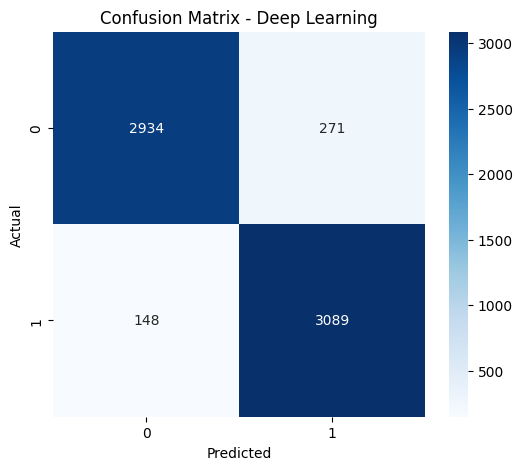

In [84]:
cm_dl = confusion_matrix(
    y_valid,
    y_pred_dl
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dl,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Deep Learning')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

TRAINING CURVES

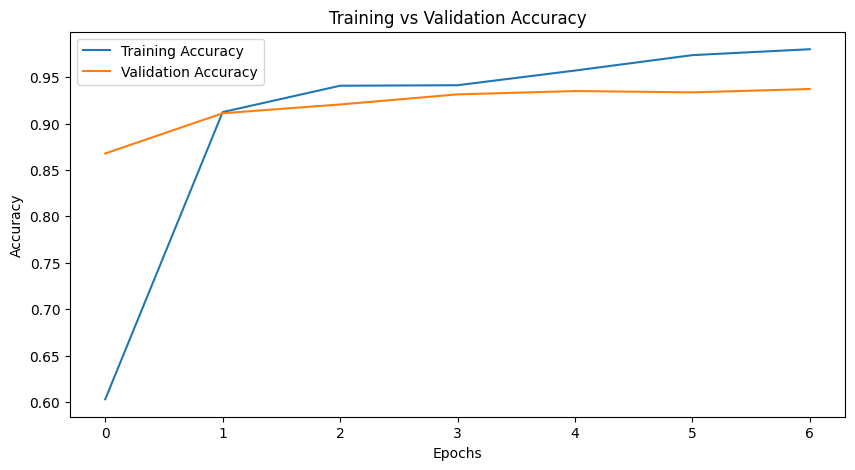

In [85]:
# Accuracy curve

plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Training vs Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

LOSS CURVE

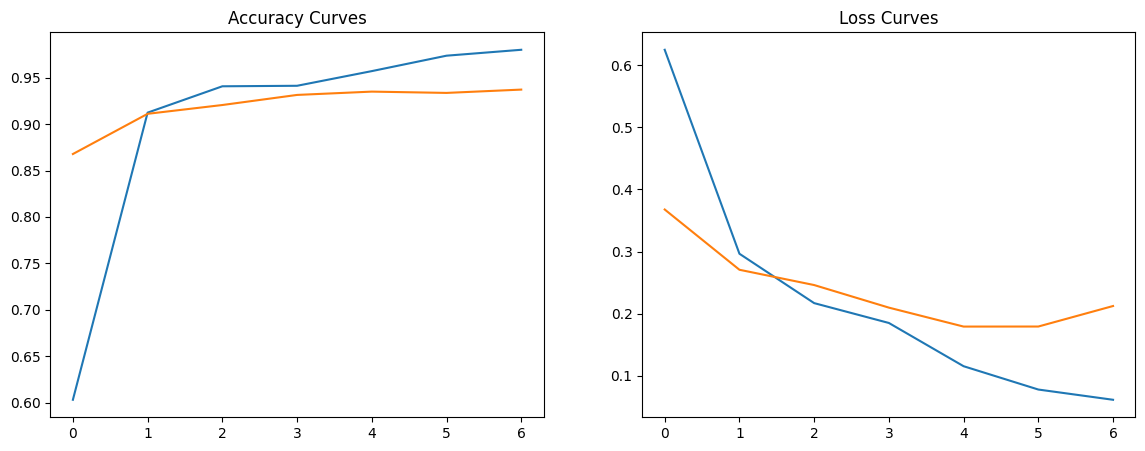

In [86]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Accuracy Curves')

ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Loss Curves')

plt.show()

ROC CURVE

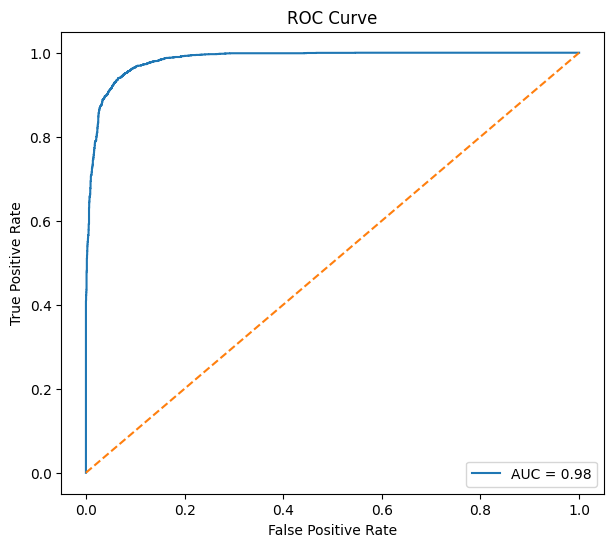

In [87]:
fpr, tpr, thresholds = roc_curve(
    y_valid,
    y_pred_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

PRECISION RECALL CURVE

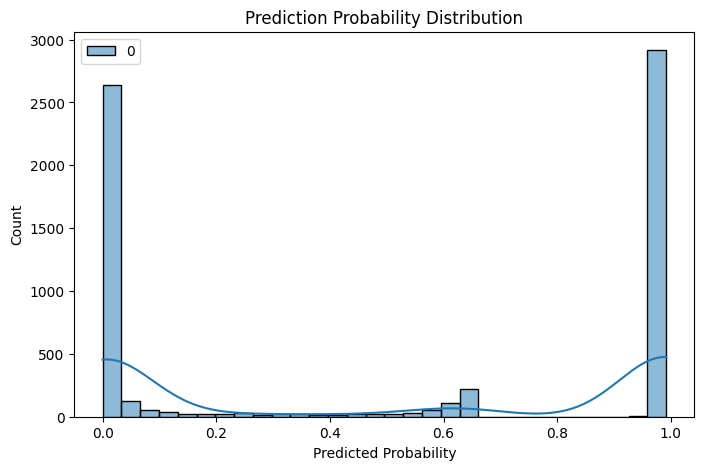

In [88]:
plt.figure(figsize=(8,5))

sns.histplot(
    y_pred_prob,
    bins=30,
    kde=True
)

plt.title('Prediction Probability Distribution')

plt.xlabel('Predicted Probability')

plt.show()

PRETRAINED GLOVE EMBEDDING + BiLSTM

In [89]:
# Download GloVe
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2026-05-13 14:40:41--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-05-13 14:40:41--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-05-13 14:40:42--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.2’

gl

In [90]:
# Unzip file
!unzip glove.6B.zip

Archive:  glove.6B.zip
replace glove.6B.50d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       A

  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       A
A



In [91]:
# Load GloVo embeddings
embedding_index = {}

with open('glove.6B.100d.txt', encoding='utf8') as f:

    for line in f:

        values = line.split()

        word = values[0]

        coefs = np.asarray(
            values[1:],
            dtype='float32'
        )

        embedding_index[word] = coefs

print('Loaded %s word vectors.' % len(embedding_index))

Loaded 400000 word vectors.


In [97]:
# An embedding matrix is created to map tokenizer vocabulary words to their corresponding pretrained GloVe vectors.

BUILD EMBEDDING MATRIX

In [92]:
embedding_dim = 100

word_index = tokenizer.word_index

embedding_matrix = np.zeros(
    (vocab_size, embedding_dim)
)

for word, i in word_index.items():

    if i < vocab_size:

        embedding_vector = embedding_index.get(word)

        if embedding_vector is not None:

            embedding_matrix[i] = embedding_vector

print(embedding_matrix.shape)

(10000, 100)


BUILD MODEL

In [93]:
glove_model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False
    ),

    Bidirectional(
        LSTM(
            64,
            return_sequences=True
        )
    ),

    GlobalAveragePooling1D(),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

COMPILE MODEL

In [94]:
glove_model.compile(

    loss='binary_crossentropy',

    optimizer='adam',

    metrics=['accuracy']
)

MODEL SUMMARY

In [95]:
glove_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

EARLY STOPPING

In [96]:
glove_early_stop = EarlyStopping(

    monitor='val_loss',

    patience=2,

    restore_best_weights=True
)

#The pretrained GloVe BiLSTM model is trained using early stopping to reduce overfitting.

FIT MODEL

In [97]:
glove_history = glove_model.fit(

    X_train_pad,
    y_train,

    validation_data=(
        X_valid_pad,
        y_valid
    ),

    epochs=10,

    batch_size=64,

    callbacks=[glove_early_stop]
)

Epoch 1/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8278 - loss: 0.3952 - val_accuracy: 0.8746 - val_loss: 0.2951
Epoch 2/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8930 - loss: 0.2627 - val_accuracy: 0.8743 - val_loss: 0.2814
Epoch 3/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9126 - loss: 0.2159 - val_accuracy: 0.9191 - val_loss: 0.1973
Epoch 4/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9263 - loss: 0.1860 - val_accuracy: 0.9263 - val_loss: 0.1829
Epoch 5/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9385 - loss: 0.1608 - val_accuracy: 0.9326 - val_loss: 0.1702
Epoch 6/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9443 - loss: 0.1438 - val_accuracy: 0.9379 - val_loss: 0.1654
Epoch 7/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9509 - loss: 0.1326 - val_accuracy: 0.9322 - val_loss: 0.1692
Epoch 8/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9554 - loss: 0.1174 - val_acc

EVALUATE

In [98]:
glove_loss, glove_accuracy = glove_model.evaluate(

    X_valid_pad,
    y_valid
)

print("GloVe BiLSTM Accuracy:", glove_accuracy)

202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9379 - loss: 0.1654
GloVe BiLSTM Accuracy: 0.9379074573516846


PREDICTIONS

In [99]:
glove_pred_prob = glove_model.predict(
    X_valid_pad
)

glove_pred = (
    glove_pred_prob > 0.5
).astype(int).ravel()

202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


F1 SCORE

In [100]:
glove_f1 = f1_score(

    y_valid,

    glove_pred,

    average='weighted'
)

print("GloVe BiLSTM F1 Score:", glove_f1)

GloVe BiLSTM F1 Score: 0.9379077155601996


CLASSIFICATION REPORT

In [101]:
print(classification_report(

    y_valid,

    glove_pred
))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94      3205
           1       0.94      0.93      0.94      3237

    accuracy                           0.94      6442
   macro avg       0.94      0.94      0.94      6442
weighted avg       0.94      0.94      0.94      6442



CONFUSION MATRIX

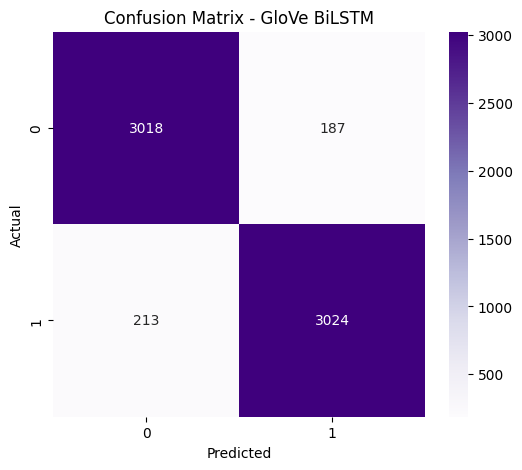

In [102]:
cm_glove = confusion_matrix(

    y_valid,

    glove_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm_glove,

    annot=True,

    fmt='d',

    cmap='Purples'
)

plt.title('Confusion Matrix - GloVe BiLSTM')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

TRAINING ACCURACY CURVE

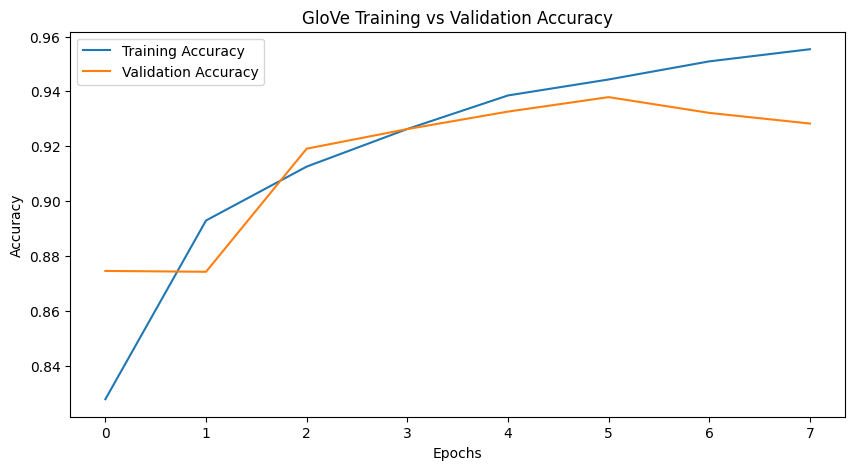

In [103]:
plt.figure(figsize=(10,5))

plt.plot(

    glove_history.history['accuracy'],

    label='Training Accuracy'
)

plt.plot(

    glove_history.history['val_accuracy'],

    label='Validation Accuracy'
)

plt.title('GloVe Training vs Validation Accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

LOSS CURVE

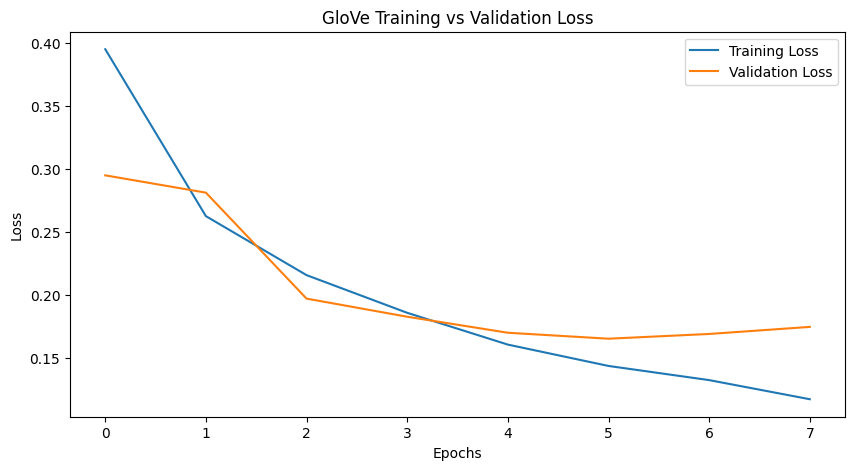

In [104]:
plt.figure(figsize=(10,5))

plt.plot(

    glove_history.history['loss'],

    label='Training Loss'
)

plt.plot(

    glove_history.history['val_loss'],

    label='Validation Loss'
)

plt.title('GloVe Training vs Validation Loss')

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.legend()

plt.show()

COMBINED CURVES

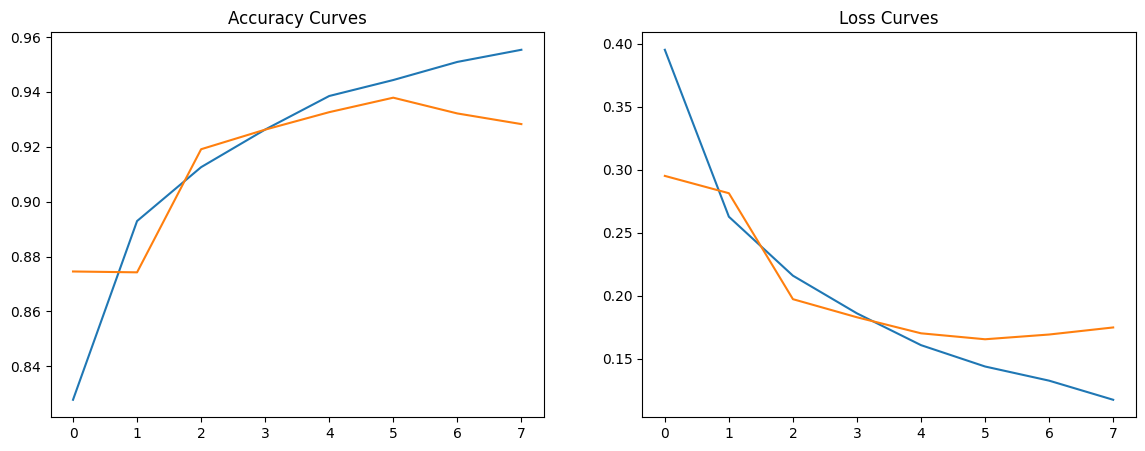

In [105]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].plot(glove_history.history['accuracy'])
ax[0].plot(glove_history.history['val_accuracy'])

ax[0].set_title('Accuracy Curves')

ax[1].plot(glove_history.history['loss'])
ax[1].plot(glove_history.history['val_loss'])

ax[1].set_title('Loss Curves')

plt.show()

ROC CURVE

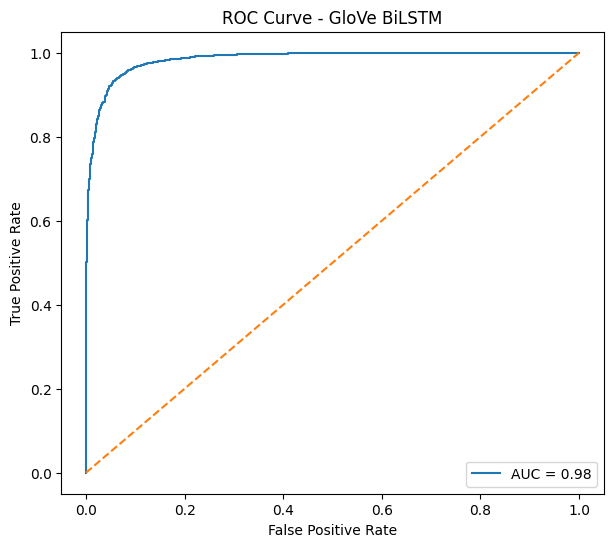

In [106]:
fpr_glove, tpr_glove, thresholds_glove = roc_curve(

    y_valid,

    glove_pred_prob.ravel()
)

roc_auc_glove = auc(

    fpr_glove,

    tpr_glove
)

plt.figure(figsize=(7,6))

plt.plot(

    fpr_glove,

    tpr_glove,

    label=f'AUC = {roc_auc_glove:.2f}'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve - GloVe BiLSTM')

plt.legend()

plt.show()

PRECISION RECALL CURVE

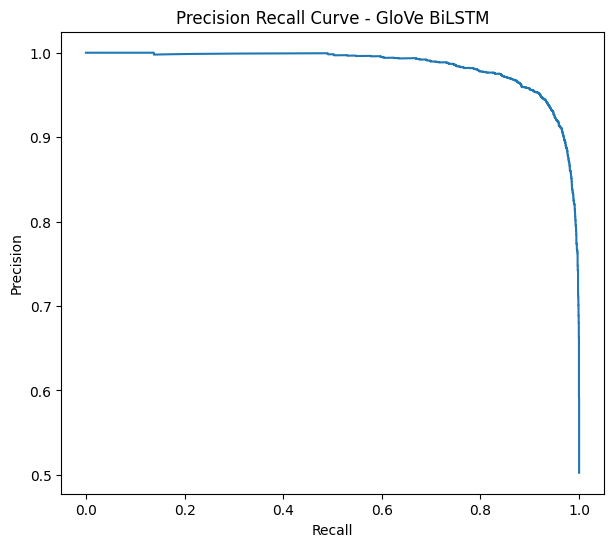

In [107]:
precision_glove, recall_glove, thresholds_glove = precision_recall_curve(

    y_valid,

    glove_pred_prob.ravel()
)

plt.figure(figsize=(7,6))

plt.plot(

    recall_glove,

    precision_glove
)

plt.xlabel('Recall')

plt.ylabel('Precision')

plt.title('Precision Recall Curve - GloVe BiLSTM')

plt.show()

PROBABILITY DISTRIBUTION

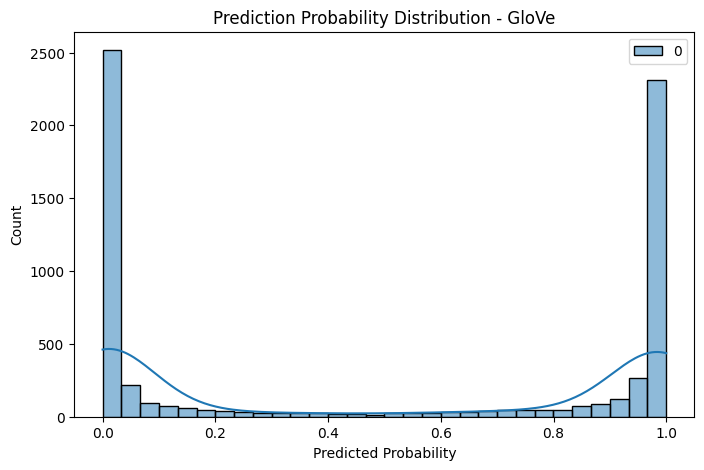

In [108]:
plt.figure(figsize=(8,5))

sns.histplot(

    glove_pred_prob,

    bins=30,

    kde=True
)

plt.title('Prediction Probability Distribution - GloVe')

plt.xlabel('Predicted Probability')

plt.show()

SAVE MODEL

In [109]:
glove_model.save('glove_bilstm_model.h5')

TINYBERT TRANSFER LEARNING

In [110]:
!pip install -U transformers datasets evaluate accelerate -q

In [111]:
import transformers
import datasets
import pyarrow

print(transformers.__version__)
print(datasets.__version__)
print(pyarrow.__version__)

5.8.1
4.8.5
24.0.0


In [123]:
# Define model name
model_name = 'distilbert-base-uncased'

TOKENIZER

In [124]:
from transformers import AutoTokenizer

In [125]:
tokenizer_hf = AutoTokenizer.from_pretrained(

    model_name,

    use_fast=False
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

PREPARE DATAFRAME

In [126]:
train_hf = pd.DataFrame({

    'text': X_train,

    'label': y_train
})

valid_hf = pd.DataFrame({

    'text': X_valid,

    'label': y_valid
})

CONVERT TO HUGGING FACE DATASETS

In [128]:
from datasets import Dataset

In [129]:
train_dataset = Dataset.from_pandas(
    train_hf
)

valid_dataset = Dataset.from_pandas(
    valid_hf
)

TOKENIZATION FUNCTION

In [130]:
def tokenize_function(example):

    return tokenizer_hf(

        example['text'],

        padding='max_length',

        truncation=True,

        max_length=256
    )

APPLY TOKENIZATION

In [131]:
tokenized_train = train_dataset.map(

    tokenize_function,

    batched=True
)

tokenized_valid = valid_dataset.map(

    tokenize_function,

    batched=True
)

Map:   0%|          | 0/25764 [00:00<?, ? examples/s]

Map:   0%|          | 0/6442 [00:00<?, ? examples/s]

LOAD PRE-TRAINED MODEL

In [132]:
hf_model = AutoModelForSequenceClassification.from_pretrained(

    model_name,

    num_labels=2
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DEFINE EVALUATION MATRIX

In [134]:
import evaluate

In [135]:
accuracy_metric = evaluate.load('accuracy')

f1_metric = evaluate.load('f1')

COMPUTE MATRIX FUNCTION

In [136]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(

        logits,

        axis=-1
    )

    accuracy = accuracy_metric.compute(

        predictions=predictions,

        references=labels
    )

    f1 = f1_metric.compute(

        predictions=predictions,

        references=labels,

        average='weighted'
    )

    return {

        'accuracy': accuracy['accuracy'],

        'f1': f1['f1']
    }

DEFINE TRAINING ARGUMENTS

In [139]:
training_args = TrainingArguments(

    output_dir='./bert_results',

    do_train=True,

    do_eval=True,

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_steps=100,

    fp16=True
)

INITIALISE TRAINER

In [140]:
trainer = Trainer(

    model=hf_model,

    args=training_args,

    train_dataset=tokenized_train,

    eval_dataset=tokenized_valid,

    compute_metrics=compute_metrics
)

TRAIN MODEL

In [141]:
trainer.train()

Step,Training Loss
100,0.359194
200,0.200455
300,0.200452
400,0.176719
500,0.196236
600,0.128363
700,0.167441
800,0.165153
900,0.163800
1000,0.143196


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4833, training_loss=0.10113997099785832, metrics={'train_runtime': 299.0706, 'train_samples_per_second': 258.441, 'train_steps_per_second': 16.16, 'total_flos': 5119335088459776.0, 'train_loss': 0.10113997099785832, 'epoch': 3.0})

EVALUATE MODEL

In [142]:
hf_results = trainer.evaluate()

print(hf_results)

Training Loss,Validation Loss,Step,Accuracy,F1
0.046075,0.155576,4833,0.967091,0.967091


{'eval_loss': 0.15557599067687988, 'eval_accuracy': 0.9670909655386526, 'eval_f1': 0.9670911177950671}


PREDICTIONS

In [143]:
predictions = trainer.predict(

    tokenized_valid
)

hf_pred = np.argmax(

    predictions.predictions,

    axis=1
)

CLASSIFICATION REPORT

In [144]:
print(classification_report(

    y_valid,

    hf_pred
))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      3205
           1       0.97      0.96      0.97      3237

    accuracy                           0.97      6442
   macro avg       0.97      0.97      0.97      6442
weighted avg       0.97      0.97      0.97      6442



CONFUSION MATRIX

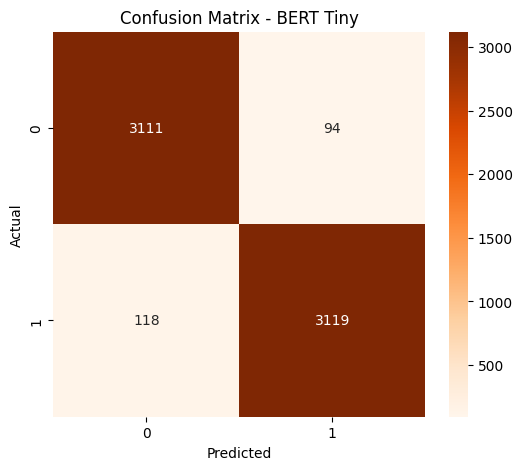

In [145]:
cm_hf = confusion_matrix(

    y_valid,

    hf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm_hf,

    annot=True,

    fmt='d',

    cmap='Oranges'
)

plt.title('Confusion Matrix - BERT Tiny')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

PREDICTION PROBABILITIES

In [146]:
hf_probs = tf.nn.softmax(

    predictions.predictions,

    axis=1
).numpy()

ROC CURVE

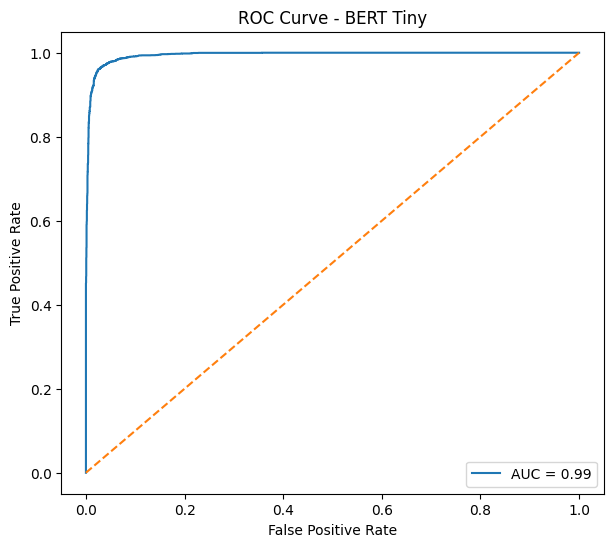

In [147]:
fpr_hf, tpr_hf, thresholds_hf = roc_curve(

    y_valid,

    hf_probs[:,1]
)

roc_auc_hf = auc(

    fpr_hf,

    tpr_hf
)

plt.figure(figsize=(7,6))

plt.plot(

    fpr_hf,

    tpr_hf,

    label=f'AUC = {roc_auc_hf:.2f}'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve - BERT Tiny')

plt.legend()

plt.show()

PRECISION RECALL CURVE

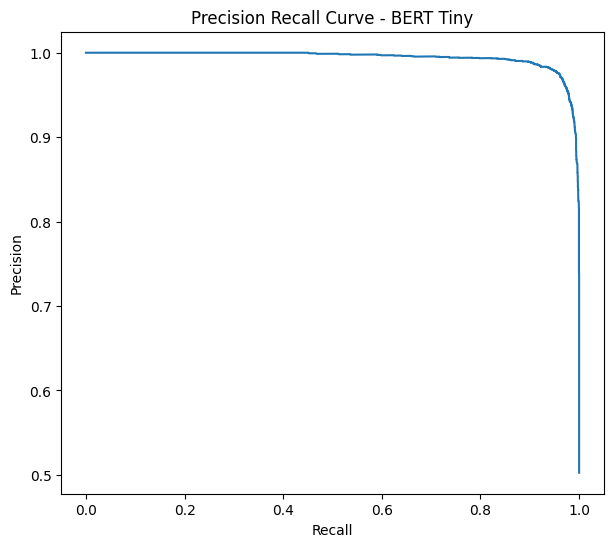

In [148]:
precision_hf, recall_hf, thresholds_hf = precision_recall_curve(

    y_valid,

    hf_probs[:,1]
)

plt.figure(figsize=(7,6))

plt.plot(

    recall_hf,

    precision_hf
)

plt.xlabel('Recall')

plt.ylabel('Precision')

plt.title('Precision Recall Curve - BERT Tiny')

plt.show()

PROBABILITY DISTRIBUTION

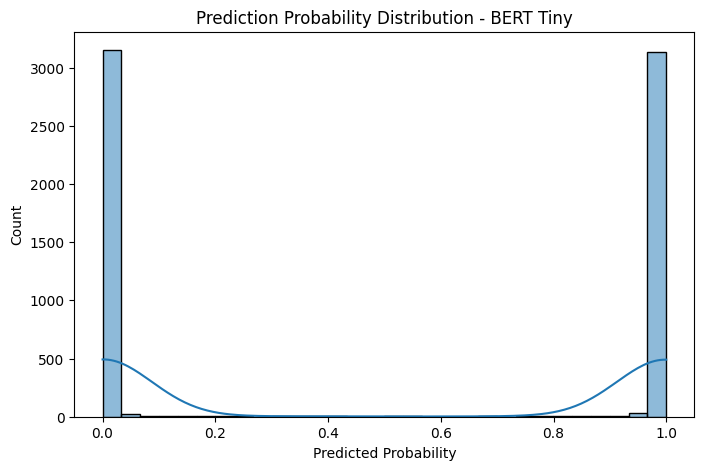

In [149]:
plt.figure(figsize=(8,5))

sns.histplot(

    hf_probs[:,1],

    bins=30,

    kde=True
)

plt.title('Prediction Probability Distribution - BERT Tiny')

plt.xlabel('Predicted Probability')

plt.show()

SAVE MODEL

In [150]:
trainer.save_model('./best_bert_tiny_model')

tokenizer_hf.save_pretrained(
    './best_bert_tiny_model'
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./best_bert_tiny_model/tokenizer_config.json',
 './best_bert_tiny_model/tokenizer.json')

FINAL COMPARISON OF ALL MODELS - need to make changes here

In [151]:
comparison_df = pd.DataFrame({

    'Model': [

        'Logistic Regression + BoW',

        'Logistic Regression + TF-IDF',

        'Random Forest + BoW',

        'GridSearch RF + BoW',

        'Advanced Randomized RF + BoW',

        'BiLSTM (Trainable Embedding)',

        'BiLSTM + GloVe Embedding',

        'BERT Tiny Transformer'
    ],

    'Accuracy': [

        accuracy_bow,

        accuracy_tfidf,

        rf_accuracy,

        best_rf_accuracy,

        advanced_rf_accuracy,

        dl_accuracy,

        glove_accuracy,

        hf_results['eval_accuracy']
    ],

    'F1 Score': [

        f1_bow,

        f1_tfidf,

        rf_f1,

        best_rf_f1,

        advanced_rf_f1,

        dl_f1,

        glove_f1,

        hf_results['eval_f1']
    ]
})

comparison_df = comparison_df.sort_values(

    by='F1 Score',

    ascending=False
)

comparison_df

,Model,Accuracy,F1 Score
7,BERT Tiny Transformer,0.967091,0.967091
6,BiLSTM + GloVe Embedding,0.937907,0.937908
5,BiLSTM (Trainable Embedding),0.934958,0.934928
0,Logistic Regression + BoW,0.927973,0.927940
1,Logistic Regression + TF-IDF,0.925799,0.925775
4,Advanced Randomized RF + BoW,0.923781,0.923776
3,GridSearch RF + BoW,0.907172,0.907170
2,Random Forest + BoW,0.851133,0.849578


VISUALIZE ALL MODELS

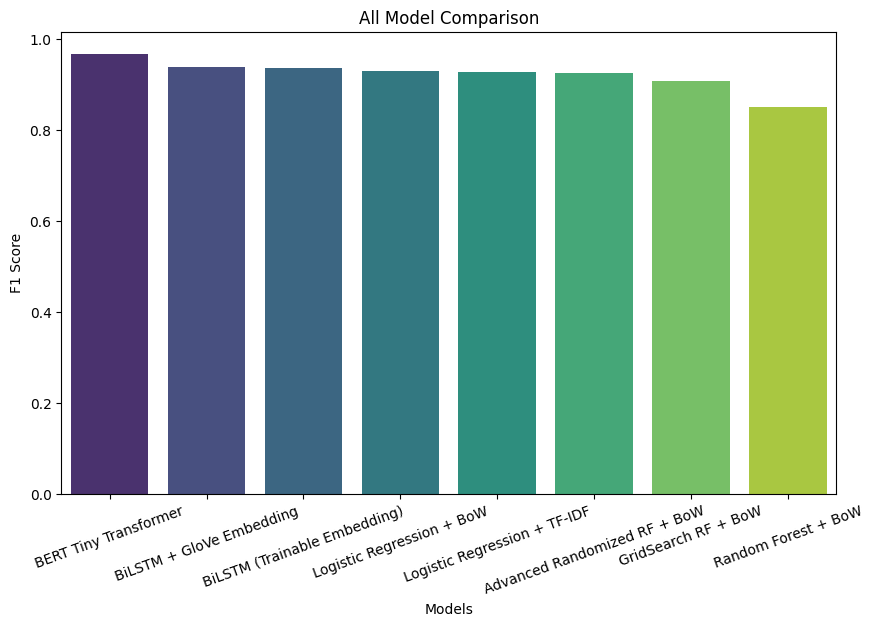

In [152]:
plt.figure(figsize=(10,6))

sns.barplot(

    x='Model',

    y='F1 Score',

    data=comparison_df,

    palette='viridis'
)

plt.xticks(rotation=20)

plt.title('All Model Comparison')

plt.xlabel('Models')

plt.ylabel('F1 Score')

plt.show()

SELECT BEST MODEL

In [153]:
best_model_index = comparison_df['F1 Score'].idxmax()

best_model_name = comparison_df.loc[
    best_model_index,
    'Model'
]

print("Best Overall Model:")
print(best_model_name)

Best Overall Model:
BERT Tiny Transformer


Best Overall Model:
BERT Tiny Transformer

SAVE THE BEST MODEL

In [154]:
trainer.save_model('./final_fake_news_model')

tokenizer_hf.save_pretrained(
    './final_fake_news_model'
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./final_fake_news_model/tokenizer_config.json',
 './final_fake_news_model/tokenizer.json')

PREDICT ON testing_data.csv

PREPARE TEST TEXT

In [155]:
X_test_final = test_df['clean_text']

CREATE TEST DATAFRAME

In [156]:
test_hf = pd.DataFrame({

    'text': X_test_final
})

CONVERT TO DATASET

In [157]:
test_dataset = Dataset.from_pandas(
    test_hf
)

TOKENIZE TEST DATA

In [158]:
tokenized_test = test_dataset.map(

    tokenize_function,

    batched=True
)

Map:   0%|          | 0/9209 [00:00<?, ? examples/s]

GENERATE PREDICTIONS

In [159]:
test_predictions = trainer.predict(

    tokenized_test
)

final_predictions = np.argmax(

    test_predictions.predictions,

    axis=1
)

REPLACE LABELS

In [160]:
test_df['label'] = final_predictions

VIEW SAMPLE OUTPUT

In [161]:
test_df.head()

,label,text,clean_text
0,0,copycat muslim terrorist arrested with assault...,copycat muslim terrorist arrested assault weapon
1,0,wow! chicago protester caught on camera admits...,wow chicago protester caught camera admits vio...
2,1,germany's fdp look to fill schaeuble's big shoes,germany fdp look fill schaeuble big shoe
3,0,mi school sends welcome back packet warning ki...,mi school sends welcome back packet warning ki...
4,1,u.n. seeks 'massive' aid boost amid rohingya '...,u n seek massive aid boost amid rohingya emerg...


EXPORT FINAL CSV

In [162]:
test_df.to_csv(

    'final_predictions.csv',

    index=False,

    header=False
)

DOWNLOAD CELL

In [163]:
from google.colab import files

files.download('final_predictions.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Multiple machine learning, deep learning, and transfer learning models were implemented and evaluated for fake news detection.

Traditional NLP models such as:
- Logistic Regression
- Random Forest

were first evaluated using:
- Bag of Words
- TF-IDF feature extraction.

Deep learning models using:
- BiLSTM
- pretrained GloVe embeddings

were then developed to improve semantic understanding.

Finally, transfer learning using the pretrained BERT Tiny transformer from Hugging Face achieved the best overall performance with approximately 96.7% accuracy and F1 score.

The transformer model demonstrated superior contextual understanding and generalization capability compared to traditional NLP approaches.

The final trained model was successfully used to predict labels for unseen testing data.